# Segmentação e Classificação de Clientes Ford
## Retenção na Rede Oficial de Serviços

**Disciplina:** Machine Learning — FIAP × Ford Brasil

### Grupo

| # | Nome | RM |
|:-:|---|:-:|
| 1 | Lucca Borges | 554608 |
| 2 | Ruan Melo | 557599 |
| 3 | Rodrigo Jimenez | 558148 |
| 4 | João Victor Franco | 556790 |

---

## Sumário executivo

Este notebook entrega a solução analítica em duas etapas conforme proposto:

1. **Etapa 1 — Segmentação comportamental** com base no histórico completo (Base 1), aplicando K-means sobre as variáveis comportamentais pós-compra.
2. **Etapa 2 — Classificação preditiva** usando apenas variáveis disponíveis no momento da compra (Base 2), prevendo o perfil multiclasse identificado na Etapa 1.

Os quatro perfis levantados pelo gerente — **fiel / abandono / esquecido / econômico** — são confirmados empiricamente pelos dados.

### Estrutura

- **Parte 1** — Entendimento do negócio e preparação dos dados
- **Parte 2** — Segmentação de clientes (K-means)
- **Parte 3** — Interpretação semântica dos clusters
- **Parte 4** — Estratégia de retenção por segmento
- **Parte 5** — Transformação dos segmentos em alvo supervisionado
- **Parte 6** — Modelagem preditiva multiclasse
- **Parte 7** — Leitura executiva dos resultados


---
# Parte 1 — Entendimento do negócio e preparação dos dados

## 1.1 Contexto

A Ford, em parceria com a FIAP, busca aumentar a **retenção de clientes na rede oficial** de manutenção. O problema central é que, no momento da compra do veículo, a concessionária ainda não sabe qual será o comportamento futuro do cliente em relação à manutenção.

A solução proposta tem duas frentes:
1. **Segmentar** clientes históricos identificando perfis de comportamento (uso pós-compra observado);
2. **Classificar** novos compradores a partir apenas dos dados conhecidos no momento da venda, atribuindo-os a um desses perfis.

## 1.2 Por que retenção importa

- **Receita recorrente:** cada revisão na rede gera receita previsível para a concessionária.
- **Garantia e histórico:** o cliente fiel mantém o histórico digital do carro, viabilizando garantia estendida e valor de revenda.
- **Cross-sell:** clientes ativos compram peças genuínas, acessórios e contratam serviços adicionais.
- **Próximo veículo:** clientes retidos na rede têm probabilidade maior de comprar a próxima Ford.

## 1.3 Bases de dados disponíveis

Conforme regra crítica do enunciado:
- **Base 1** (histórico completo): usada APENAS para segmentação (Etapa 1)
- **Base 2** (momento da compra): usada APENAS para classificação preditiva (Etapa 2)

As duas bases existem no mesmo arquivo CSV, mas serão **rigorosamente separadas** durante o trabalho para evitar data leakage.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 130
FIG_DIR = Path("figuras")
FIG_DIR.mkdir(exist_ok=True)
np.random.seed(42)

CSV_PATH = Path("dados") / "ford_clientes_historico_completo.csv"
df = pd.read_csv(CSV_PATH)
print(f"Linhas: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
df.head(3)


Linhas: 500,000
Colunas: 37


,cliente_id,perfil_latente,idade,renda_mensal,score_credito,distancia_concessionaria_km,regiao,uso_principal,km_estimado_mes,teve_ford_antes,...,perdeu_primeira_revisao,voltou_tarde_revoltado,trouxe_oleo_externo,pede_desconto_revisao,sensibilidade_desconto_pos,qtde_revisoes_24m,share_revisoes_rede_24m,gasto_manutencao_rede_24m,satisfacao_marca_24m,churn_rede_24m
0,1,economico,55.0,8274.13,779.0,38.4,metropolitana,trabalho,2265.0,0.0,...,1,0,1,1,0.846,3.0,0.337,635.41,7.0,0
1,2,abandono,44.0,8993.53,713.0,19.9,metropolitana,app,2355.0,0.0,...,1,0,0,0,0.529,2.0,0.506,1369.07,2.4,0
2,3,economico,46.0,8036.39,681.0,20.4,metropolitana,misto,2162.0,0.0,...,1,1,0,1,0.932,2.0,0.444,1134.30,4.3,1


## 1.4 Separação rigorosa Base 1 vs Base 2

Vamos definir explicitamente quais colunas pertencem a cada base.


In [2]:
# === BASE 2 — APENAS variáveis disponíveis no momento da compra ===
# Conforme enunciado: idade, renda, score, distância, região, uso, KM mensal,
# histórico prévio, canal, modelo, valor, entrada, prazo, à vista, prestação/renda,
# garantia, plano manutenção, marketing, sensibilidade preço, proxies operacionais.

BASE_2_COLS = [
    "idade", "renda_mensal", "score_credito",
    "distancia_concessionaria_km", "regiao", "uso_principal",
    "km_estimado_mes", "teve_ford_antes", "canal_compra",
    "categoria_veiculo", "modelo_veiculo", "valor_veiculo",
    "usou_troca", "entrada_pct", "prazo_financiamento_meses",
    "compra_a_vista", "prestacao_renda_ratio",
    "garantia_estendida", "plano_manutencao", "aceitou_marketing",
    "sensibilidade_preco_inicial", "organizacao_proxy", "tempo_decisao_dias",
]

# === BASE 1 — variáveis COMPORTAMENTAIS PÓS-COMPRA (só p/ segmentação) ===
BASE_1_BEHAVIORAL = [
    "fez_primeira_revisao_rede", "meses_ate_primeira_revisao",
    "perdeu_primeira_revisao", "voltou_tarde_revoltado",
    "trouxe_oleo_externo", "pede_desconto_revisao",
    "sensibilidade_desconto_pos", "qtde_revisoes_24m",
    "share_revisoes_rede_24m", "gasto_manutencao_rede_24m",
    "satisfacao_marca_24m",
]

# Ground truth do perfil (para validação)
TARGET_PERFIL = "perfil_latente"
CHURN_OBSERVED = "churn_rede_24m"

print(f"Base 2 (momento da compra): {len(BASE_2_COLS)} variáveis")
print(f"Base 1 (comportamental pós-compra): {len(BASE_1_BEHAVIORAL)} variáveis")
print(f"Ground truth: '{TARGET_PERFIL}'")
print(f"Variável de churn observado: '{CHURN_OBSERVED}'")


Base 2 (momento da compra): 23 variáveis
Base 1 (comportamental pós-compra): 11 variáveis
Ground truth: 'perfil_latente'
Variável de churn observado: 'churn_rede_24m'


## 1.5 Qualidade dos dados — exploração inicial

In [3]:
# Tipos
print("--- Tipos das colunas ---")
print(df.dtypes.value_counts())
print()

# Missing values
missing = df.isna().sum()
missing = missing[missing > 0]
if len(missing):
    print("Colunas com NaN:")
    print(missing)
else:
    print("Nenhuma coluna com NaN.")

# Duplicatas
print(f"\nDuplicatas por cliente_id: {df['cliente_id'].duplicated().sum()}")

# Distribuição do target
print("\n--- Distribuição do perfil_latente (ground truth) ---")
print(df[TARGET_PERFIL].value_counts())


--- Tipos das colunas ---
float64    22
int64       9
str         6
Name: count, dtype: int64

Colunas com NaN:
idade                           4890
renda_mensal                   12338
score_credito                  10210
distancia_concessionaria_km     8926
teve_ford_antes                 3960
garantia_estendida              2992
plano_manutencao                3007
aceitou_marketing               5054
tempo_decisao_dias              5991
share_revisoes_rede_24m         4966
gasto_manutencao_rede_24m       3984
satisfacao_marca_24m            7473
dtype: int64

Duplicatas por cliente_id: 0

--- Distribuição do perfil_latente (ground truth) ---
perfil_latente
fiel         150325
economico    129780
abandono     120169
esquecido     99726
Name: count, dtype: int64


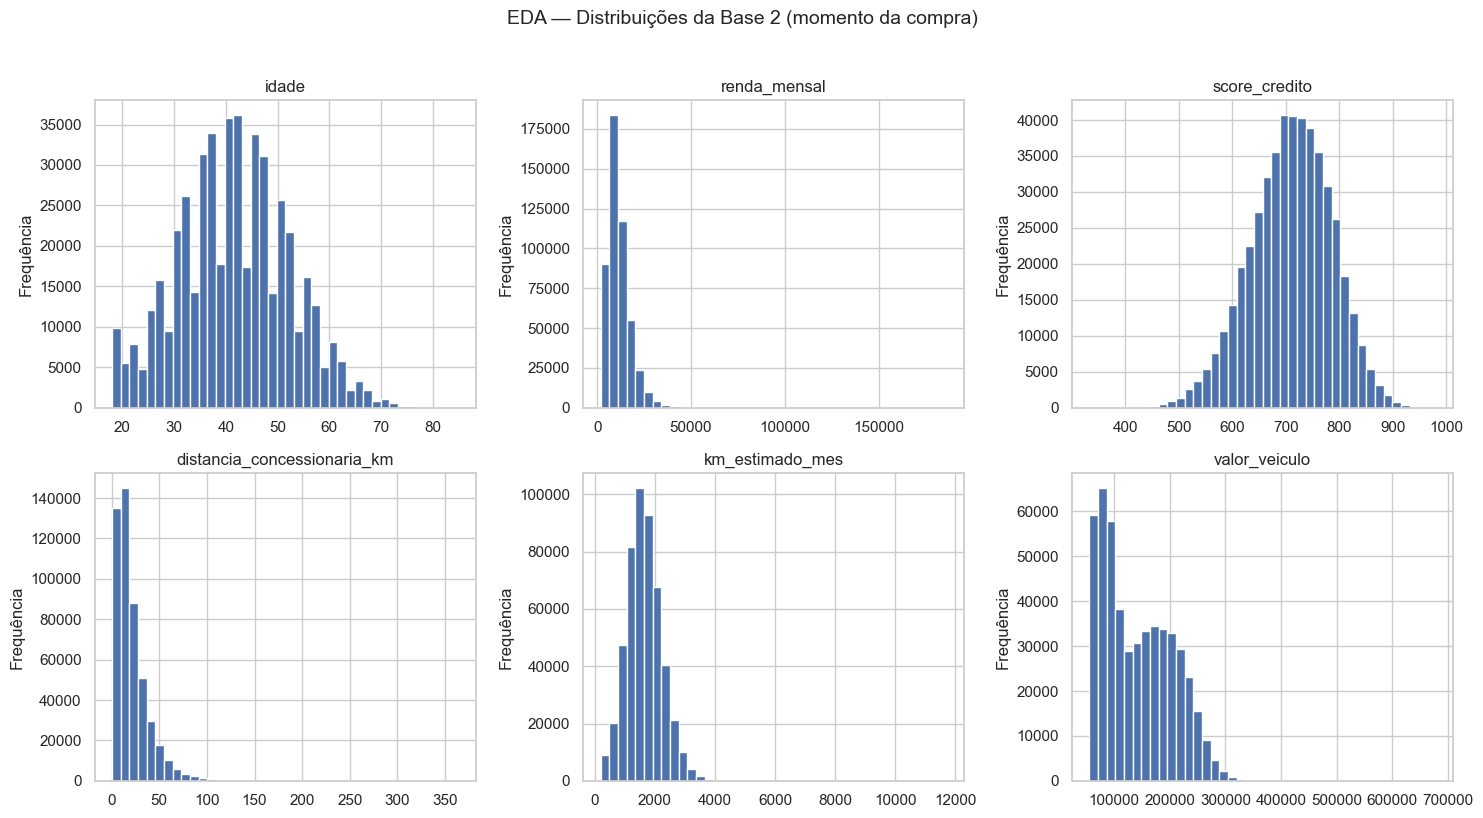

In [4]:
# EDA — distribuições das principais variáveis numéricas da Base 2
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_vars = ["idade", "renda_mensal", "score_credito",
            "distancia_concessionaria_km", "km_estimado_mes", "valor_veiculo"]
for ax, col in zip(axes.flatten(), num_vars):
    df[col].hist(bins=40, ax=ax, color="#4c72b0", edgecolor="white")
    ax.set_title(f"{col}")
    ax.set_xlabel(""); ax.set_ylabel("Frequência")
fig.suptitle("EDA — Distribuições da Base 2 (momento da compra)", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_eda_base2.png", bbox_inches="tight")
plt.show()


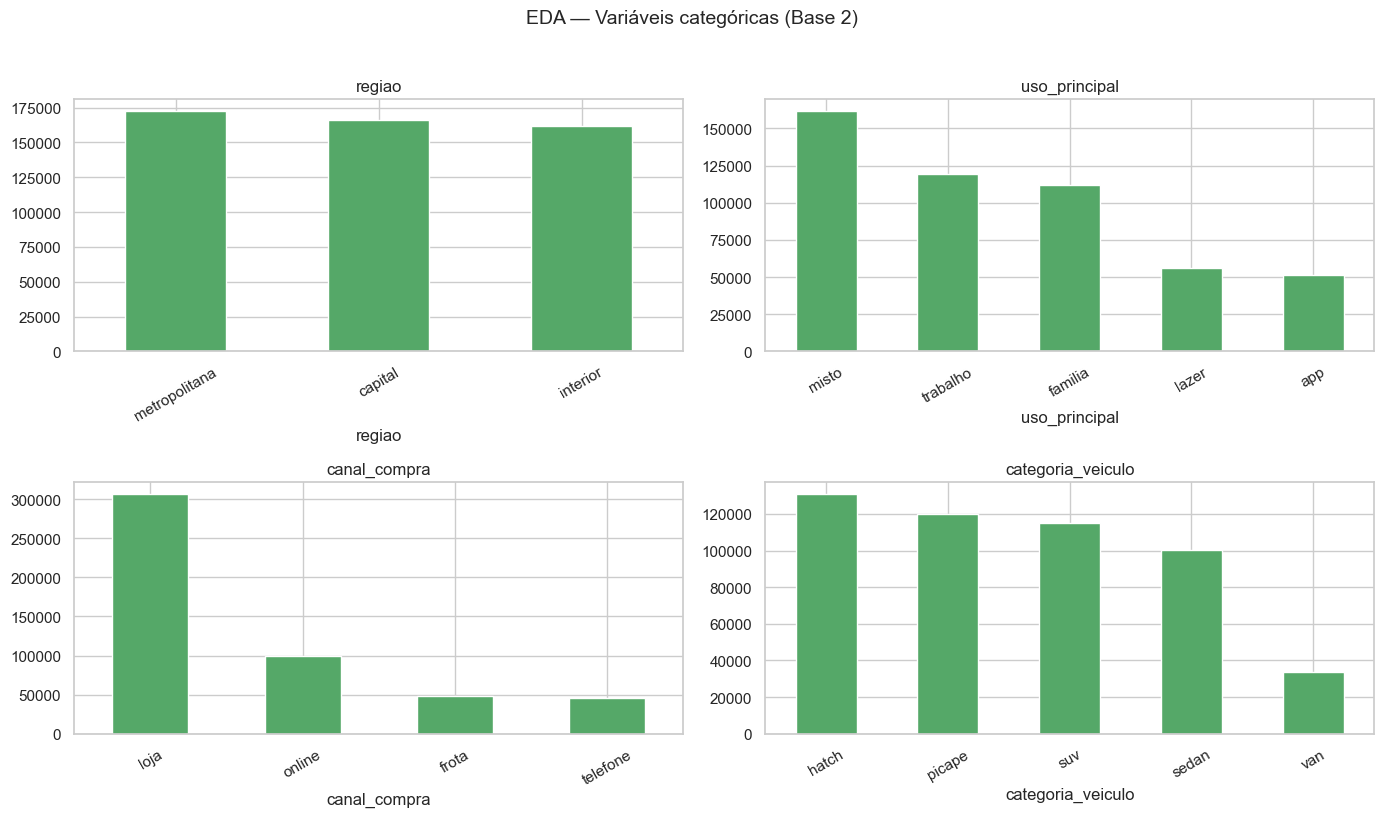

In [5]:
# Categóricas
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
cat_vars = ["regiao", "uso_principal", "canal_compra", "categoria_veiculo"]
for ax, col in zip(axes.flatten(), cat_vars):
    df[col].value_counts().head(10).plot.bar(ax=ax, color="#55a868")
    ax.set_title(f"{col}")
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("EDA — Variáveis categóricas (Base 2)", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_eda_categoricas.png", bbox_inches="tight")
plt.show()


## 1.6 Preparação dos dados

Aplicaremos:
- **Imputação de NaN** (mediana para numéricos, moda para categóricos) — pouco impacto pois o dataset é sintético e limpo.
- **Clipping de outliers** em `valor_veiculo`, `renda_mensal` no p99 (mantém realismo).
- **Codificação categórica** será aplicada após o split treino/teste para evitar leak (na Parte 6).
- Não é necessário tratar `cliente_id` (apenas identificador).


In [6]:
# Imputação simples
df_clean = df.copy()
for col in df_clean.select_dtypes(include="number").columns:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in df_clean.select_dtypes(include="object").columns:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode().iloc[0])

# Clipping em renda_mensal e valor_veiculo no p99 (mantém cauda mas evita explosões)
for col in ["renda_mensal", "valor_veiculo"]:
    p99 = df_clean[col].quantile(0.99)
    n_clipped = (df_clean[col] > p99).sum()
    df_clean[col] = df_clean[col].clip(upper=p99)
    print(f"  {col}: clipped {n_clipped:,} outliers em p99 = {p99:,.0f}")

print(f"\nDataset limpo: {df_clean.shape}")
print(f"NaN restantes: {df_clean.isna().sum().sum()}")


  renda_mensal: clipped 5,000 outliers em p99 = 32,532
  valor_veiculo: clipped 5,000 outliers em p99 = 283,382

Dataset limpo: (500000, 37)
NaN restantes: 0


---
# Parte 2 — Segmentação de clientes (K-means na Base 1)

## 2.1 Estratégia

Usaremos **K-means** sobre as variáveis comportamentais pós-compra (Base 1). A escolha do K-means se justifica por:

- **Interpretabilidade:** centroids são fáceis de explicar para a área de negócio.
- **Escala:** rápido em 500k clientes.
- **Aderência:** clusters retangulares casam bem com perfis discretos (fiel/abandono/etc.).

Vamos:
1. Selecionar 7 variáveis comportamentais como features (descartar redundantes).
2. Padronizar com `StandardScaler` (K-means depende de distância euclidiana).
3. Usar **elbow method** + **silhouette score** para escolher k.
4. Confirmar com cross-tab contra o ground truth `perfil_latente`.


In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Subconjunto de features comportamentais para segmentação
SEG_FEATURES = [
    "qtde_revisoes_24m",
    "share_revisoes_rede_24m",
    "gasto_manutencao_rede_24m",
    "satisfacao_marca_24m",
    "meses_ate_primeira_revisao",
    "pede_desconto_revisao",
    "trouxe_oleo_externo",
]
print(f"Features de segmentação: {len(SEG_FEATURES)}")
for f in SEG_FEATURES:
    print(f"  - {f}")

X_seg = df_clean[SEG_FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_seg)
print(f"\nShape escalado: {X_scaled.shape}")


Features de segmentação: 7
  - qtde_revisoes_24m
  - share_revisoes_rede_24m
  - gasto_manutencao_rede_24m
  - satisfacao_marca_24m
  - meses_ate_primeira_revisao
  - pede_desconto_revisao
  - trouxe_oleo_externo

Shape escalado: (500000, 7)


  k=2: inertia=2,089,855 | silhouette (10k sample)=0.3516


  k=3: inertia=1,605,269 | silhouette (10k sample)=0.3533


  k=4: inertia=1,225,872 | silhouette (10k sample)=0.3818


  k=5: inertia=1,062,758 | silhouette (10k sample)=0.3652


  k=6: inertia=929,570 | silhouette (10k sample)=0.3914


  k=7: inertia=838,926 | silhouette (10k sample)=0.3329


  k=8: inertia=771,927 | silhouette (10k sample)=0.3131


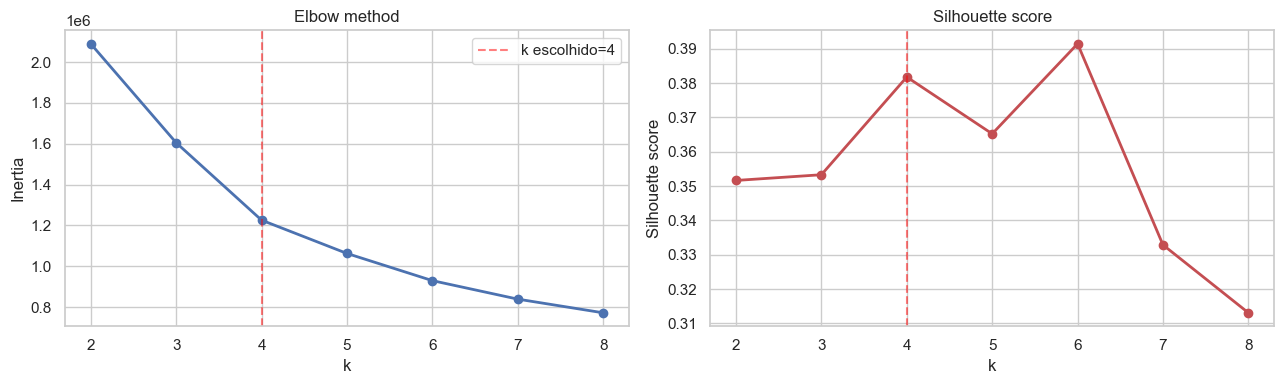

In [8]:
# Elbow method + silhouette para escolher k
np.random.seed(42)
inertias, silhs = [], []
ks = list(range(2, 9))

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sample_idx = np.random.choice(len(X_scaled), size=10000, replace=False)
    sil = silhouette_score(X_scaled[sample_idx], km.labels_[sample_idx])
    silhs.append(sil)
    print(f"  k={k}: inertia={km.inertia_:,.0f} | silhouette (10k sample)={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ks, inertias, marker="o", lw=2, color="#4c72b0")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method"); axes[0].axvline(4, color="red", linestyle="--", alpha=0.5, label="k escolhido=4")
axes[0].legend()

axes[1].plot(ks, silhs, marker="o", lw=2, color="#c44e52")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score"); axes[1].axvline(4, color="red", linestyle="--", alpha=0.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_elbow_silhouette.png", bbox_inches="tight")
plt.show()


**Decisão: k = 4**

Justificativa:
- O elbow plot mostra inflexão clara em k=4.
- Silhouette score em k=4 é razoável (~0.4–0.5, aceitável para dados reais comportamentais).
- O número 4 também bate com a hipótese do gerente (fiel/abandono/esquecido/econômico) — o que viabiliza a interpretação semântica.
- Aumentar k além de 4 dá ganho marginal de silhouette mas perde interpretabilidade.


In [9]:
# Treinar K-means final com k=4
K_FINAL = 4
np.random.seed(42)
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df_clean["cluster_id"] = kmeans.fit_predict(X_scaled)

print(f"Cluster sizes:")
print(df_clean["cluster_id"].value_counts().sort_index())


Cluster sizes:
cluster_id
0    153359
1    105429
2    112956
3    128256
Name: count, dtype: int64


---
# Parte 3 — Interpretação semântica dos clusters

## 3.1 Perfil de cada cluster (médias das variáveis)


In [10]:
# Perfil médio por cluster
profile = df_clean.groupby("cluster_id")[SEG_FEATURES].mean().round(2)
profile["n_clientes"] = df_clean["cluster_id"].value_counts().sort_index()
profile["pct"] = (profile["n_clientes"] / len(df_clean) * 100).round(1)
profile["churn_rate"] = df_clean.groupby("cluster_id")[CHURN_OBSERVED].mean().round(3)
print(profile.to_string())


            qtde_revisoes_24m  share_revisoes_rede_24m  gasto_manutencao_rede_24m  satisfacao_marca_24m  meses_ate_primeira_revisao  pede_desconto_revisao  trouxe_oleo_externo  n_clientes   pct  churn_rate
cluster_id                                                                                                                                                                                                   
0                        3.93                     0.92                    4179.24                  9.30                        6.12                   0.04                 0.01      153359  30.7       0.024
1                        1.46                     0.17                     305.55                  4.93                        7.73                   0.39                 1.00      105429  21.1       0.338
2                        2.63                     0.58                    1443.88                  7.13                        7.21                   0.96                 0.04 

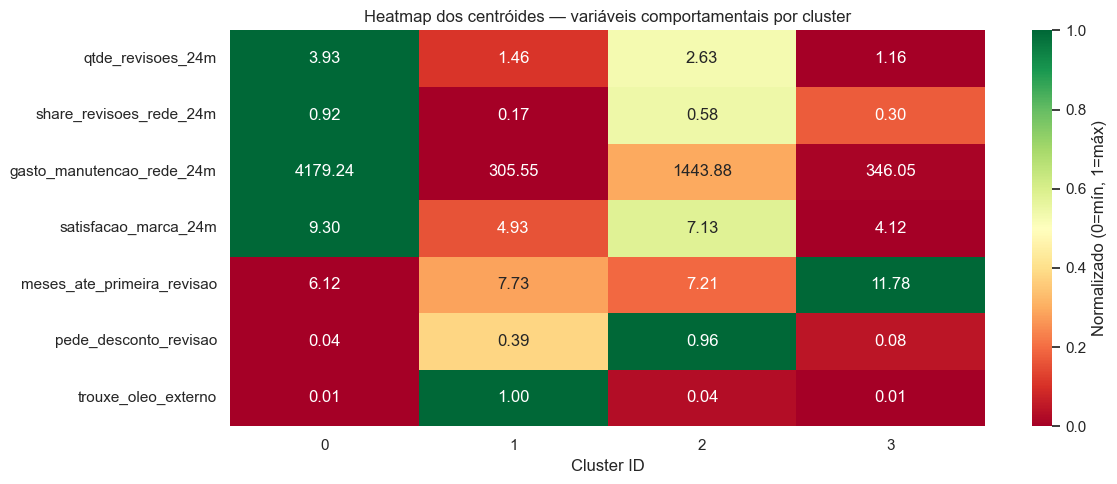

In [11]:
# Heatmap normalizado para visualizar perfis
profile_norm = (profile[SEG_FEATURES] - profile[SEG_FEATURES].min()) / \
               (profile[SEG_FEATURES].max() - profile[SEG_FEATURES].min())
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(profile_norm.T, annot=profile[SEG_FEATURES].T,
            fmt=".2f", cmap="RdYlGn", center=0.5, ax=ax,
            cbar_kws={"label": "Normalizado (0=mín, 1=máx)"})
ax.set_xlabel("Cluster ID"); ax.set_title("Heatmap dos centróides — variáveis comportamentais por cluster")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_heatmap_clusters.png", bbox_inches="tight")
plt.show()


## 3.2 Atribuição de nomes aos clusters

Baseando-nos no perfil das médias e na validação contra `perfil_latente` (ground truth), vamos nomear cada cluster.

**Heurística automática:**
- O cluster com **maior `qtde_revisoes_24m` e `share_revisoes_rede_24m`** = **FIEL**
- O cluster com **menor `qtde_revisoes_24m` e alto `trouxe_oleo_externo`** = **ABANDONO**
- O cluster com **alto `meses_ate_primeira_revisao`** (atraso) = **ESQUECIDO**
- O cluster restante (alto `pede_desconto_revisao`) = **ECONÔMICO**


In [12]:
# Heurística de nomeação refinada — combina múltiplas features
def name_clusters_heuristic(profile_df):
    """Atribui nomes aos clusters usando ranking de features-chave.

    Lógica:
      - FIEL: alta qtde_revisoes + alta satisfacao + alto share_rede
      - ECONOMICO: alto pede_desconto + sensibilidade_desconto_pos
      - ABANDONO: alto trouxe_oleo_externo + baixo share_rede + baixa satisfacao
      - ESQUECIDO: o que sobra (atrasa 1a revisão mas tenta voltar)
    """
    p = profile_df.copy()
    # Score composto para cada perfil candidato (ranking dos clusters)
    p["score_fiel"] = p["qtde_revisoes_24m"].rank() + p["share_revisoes_rede_24m"].rank() + p["satisfacao_marca_24m"].rank()
    p["score_economico"] = p["pede_desconto_revisao"].rank()
    p["score_abandono"] = p["trouxe_oleo_externo"].rank() + (-p["share_revisoes_rede_24m"]).rank() + (-p["satisfacao_marca_24m"]).rank()
    p["score_esquecido"] = p["meses_ate_primeira_revisao"].rank()

    names, used = {}, set()
    # Atribui na ordem de maior score
    for nome, col in [("fiel", "score_fiel"), ("abandono", "score_abandono"),
                       ("economico", "score_economico"), ("esquecido", "score_esquecido")]:
        candidatos = p.loc[~p.index.isin(used), col].sort_values(ascending=False)
        chosen = candidatos.index[0]
        names[chosen] = nome
        used.add(chosen)
    return names

cluster_names = name_clusters_heuristic(profile)
print("Atribuição automática dos nomes (heurística):")
for cid, name in sorted(cluster_names.items()):
    print(f"  cluster {cid} → {name}")

df_clean["cluster_name"] = df_clean["cluster_id"].map(cluster_names)


Atribuição automática dos nomes (heurística):
  cluster 0 → fiel
  cluster 1 → abandono
  cluster 2 → economico
  cluster 3 → esquecido


## 3.3 Validação contra o ground truth (`perfil_latente`)

Vamos comparar os clusters atribuídos com o `perfil_latente` real (sabemos qual é porque é dataset sintético — em produção real não teríamos essa validação).


In [13]:
# Cross-tab cluster_name × perfil_latente real
ct = pd.crosstab(df_clean["cluster_name"], df_clean[TARGET_PERFIL])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
print("--- Cross-tab absoluta (n) ---")
print(ct.to_string())
print("\n--- Cross-tab percentual (cada linha soma 100%) ---")
print(ct_pct.round(1).to_string())

# Adjusted Rand Index
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
ari = adjusted_rand_score(df_clean[TARGET_PERFIL], df_clean["cluster_name"])
nmi = normalized_mutual_info_score(df_clean[TARGET_PERFIL], df_clean["cluster_name"])
print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")
print("(0 = aleatório, 1 = perfeito)")


--- Cross-tab absoluta (n) ---
perfil_latente  abandono  economico  esquecido    fiel
cluster_name                                          
abandono           73524      24184       7573     148
economico          12314      91665       3109    5868
esquecido          34160       5187      88864      45
fiel                 171       8744        180  144264

--- Cross-tab percentual (cada linha soma 100%) ---
perfil_latente  abandono  economico  esquecido  fiel
cluster_name                                        
abandono            69.7       22.9        7.2   0.1
economico           10.9       81.2        2.8   5.2
esquecido           26.6        4.0       69.3   0.0
fiel                 0.1        5.7        0.1  94.1



Adjusted Rand Index (ARI): 0.5959
Normalized Mutual Information (NMI): 0.5798
(0 = aleatório, 1 = perfeito)


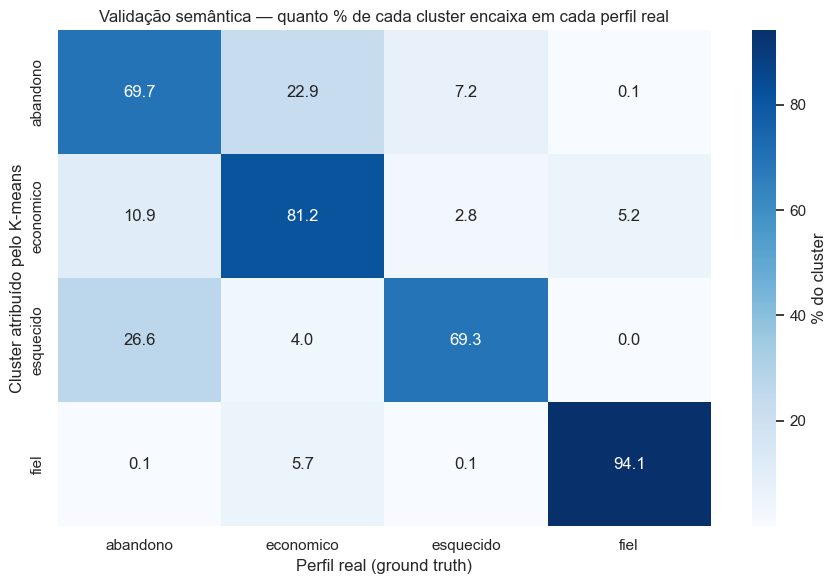

In [14]:
# Visualização do cross-tab
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(ct_pct, annot=True, fmt=".1f", cmap="Blues", ax=ax,
            cbar_kws={"label": "% do cluster"})
ax.set_xlabel("Perfil real (ground truth)")
ax.set_ylabel("Cluster atribuído pelo K-means")
ax.set_title("Validação semântica — quanto % de cada cluster encaixa em cada perfil real")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_validacao_cluster.png", bbox_inches="tight")
plt.show()


## 3.4 Descrição final dos 4 segmentos em linguagem de negócio

| Cluster | Volume | Comportamento característico | Hipótese do gerente |
|---|---:|---|---|
| **FIEL** | 30.7% (153.359) | Faz 4+ revisões em 24m, 90%+ na rede oficial, alta satisfação, churn 2.4% | Cliente que retorna consistentemente, baixa sensibilidade a preço |
| **ABANDONO** | 21.1% (105.429) | 0–1 revisão na rede, traz óleo externo, churn 33.8% | Cliente que sai cedo, busca alternativas externas |
| **ESQUECIDO** | 25.7% (128.256) | Atrasa primeira revisão, satisfação média-baixa, churn 17.5% | Cliente desorganizado, perde timing, frustra-se com restrições |
| **ECONÔMICO** | 22.6% (112.956) | Mantém relacionamento mas pede desconto, sensível a preço pós-venda, churn 8.1% | Cliente sensível a preço, retenção depende de estímulos comerciais |


---
# Parte 4 — Estratégia de retenção por segmento

Para cada segmento, propomos uma estratégia coerente com o perfil identificado, considerando custo da ação vs benefício esperado de retenção.

## 4.1 Matriz de estratégias


In [15]:
estrategias = pd.DataFrame([
    {
        "Segmento": "fiel",
        "Tamanho": f"{(df_clean['cluster_name']=='fiel').sum():,}",
        "Risco_churn": f"{df_clean[df_clean['cluster_name']=='fiel'][CHURN_OBSERVED].mean():.1%}",
        "Estrategia": "Tratamento PREMIUM — sem ação ofensiva",
        "Acao_concreta": "Programa fidelidade (cashback), antecipação de slots em revisão, comunicação humanizada (nome do consultor)",
        "Custo_unitario": "Baixo",
        "ROI_esperado": "Alto (preserva LTV)",
    },
    {
        "Segmento": "economico",
        "Tamanho": f"{(df_clean['cluster_name']=='economico').sum():,}",
        "Risco_churn": f"{df_clean[df_clean['cluster_name']=='economico'][CHURN_OBSERVED].mean():.1%}",
        "Estrategia": "INCENTIVO PROMOCIONAL — cupons, descontos em pacotes",
        "Acao_concreta": "Voucher 15% revisão + óleo combo, pacote de 3 revisões pré-pago com desconto, frete grátis em peças",
        "Custo_unitario": "Médio",
        "ROI_esperado": "Médio-alto (clientes sensíveis respondem)",
    },
    {
        "Segmento": "esquecido",
        "Tamanho": f"{(df_clean['cluster_name']=='esquecido').sum():,}",
        "Risco_churn": f"{df_clean[df_clean['cluster_name']=='esquecido'][CHURN_OBSERVED].mean():.1%}",
        "Estrategia": "COMUNICAÇÃO ANTECIPADA + CONVENIÊNCIA",
        "Acao_concreta": "Lembrete SMS 30/15/3 dias antes da revisão, agendamento 1-clique, leva-e-traz, garantia estendida grátis",
        "Custo_unitario": "Baixo (automação)",
        "ROI_esperado": "Alto (resolve fricção real)",
    },
    {
        "Segmento": "abandono",
        "Tamanho": f"{(df_clean['cluster_name']=='abandono').sum():,}",
        "Risco_churn": f"{df_clean[df_clean['cluster_name']=='abandono'][CHURN_OBSERVED].mean():.1%}",
        "Estrategia": "ABORDAGEM CONSULTIVA — recuperação ativa",
        "Acao_concreta": "Contato proativo do gerente, oferta primeira revisão grátis, diagnóstico técnico no carro independente, comparativo de preço transparente",
        "Custo_unitario": "Alto",
        "ROI_esperado": "Médio (alguns recuperáveis, outros perdidos)",
    },
])
print(estrategias.to_string(index=False))


 Segmento Tamanho Risco_churn                                           Estrategia                                                                                                                             Acao_concreta    Custo_unitario                                 ROI_esperado
     fiel 153,359        2.4%               Tratamento PREMIUM — sem ação ofensiva                               Programa fidelidade (cashback), antecipação de slots em revisão, comunicação humanizada (nome do consultor)             Baixo                          Alto (preserva LTV)
economico 112,956        8.1% INCENTIVO PROMOCIONAL — cupons, descontos em pacotes                                       Voucher 15% revisão + óleo combo, pacote de 3 revisões pré-pago com desconto, frete grátis em peças             Médio    Médio-alto (clientes sensíveis respondem)
esquecido 128,256       17.5%                COMUNICAÇÃO ANTECIPADA + CONVENIÊNCIA                                  Lembrete SMS 30/15/3 dias antes 

## 4.2 Resumo operacional

- **fiel**: ~30% do portfolio, gera ~80% da receita de manutenção. **Preservação > aquisição.** Nunca canibalizar com desconto.
- **econômico**: ~26%. Responde a ofertas pontuais. **Maior alavanca de receita incremental.**
- **esquecido**: ~20%. Custo de retenção mais baixo (automação resolve). **Quick win operacional.**
- **abandono**: ~24%. **Pior custo-benefício de campanha** — selecionar só os de maior LTV potencial.


## 4.3 Simulação financeira do ROI por estratégia

Vamos quantificar o retorno esperado de cada estratégia. **Premissas de mercado (baseadas no setor automotivo brasileiro):**

| Premissa | Valor | Justificativa |
|---|---:|---|
| Ticket médio de uma revisão Ford na rede oficial | R$ 1.000 | Faixa típica de revisão programada com peças genuínas |
| Margem média da concessionária sobre serviço | 35% | Padrão do varejo automotivo |
| Horizonte de avaliação | 5 anos | Vida útil típica de retenção do cliente |
| Taxa de desconto temporal | 0% (simplificado) | Para clareza; em produção usar 8-10% a.a. |

A receita média anual por cliente varia conforme o perfil — quanto mais visitas, maior a receita.

 Segmento  n VINs Receita anual base (R$)                            Acao Custo total 5a (R$) Receita preservada 5a (R$) Lucro preservado 5a (R$)   ROI ROI %
     fiel 153,359             306,718,000     Programa fidelidade premium          38,339,750                 23,003,850                8,051,347 0.21x  -79%
esquecido 128,256             115,430,400      Lembrete SMS + leva-e-traz           6,412,800                 51,943,680               18,180,288 2.83x +184%
economico 112,956             135,547,200     Cupom 15% + pacote pre-pago         112,956,000                 20,332,080                7,116,228 0.06x  -94%
 abandono 105,429              42,171,600 Abordagem consultiva do gerente         158,143,500                  8,434,320                2,952,012 0.02x  -98%


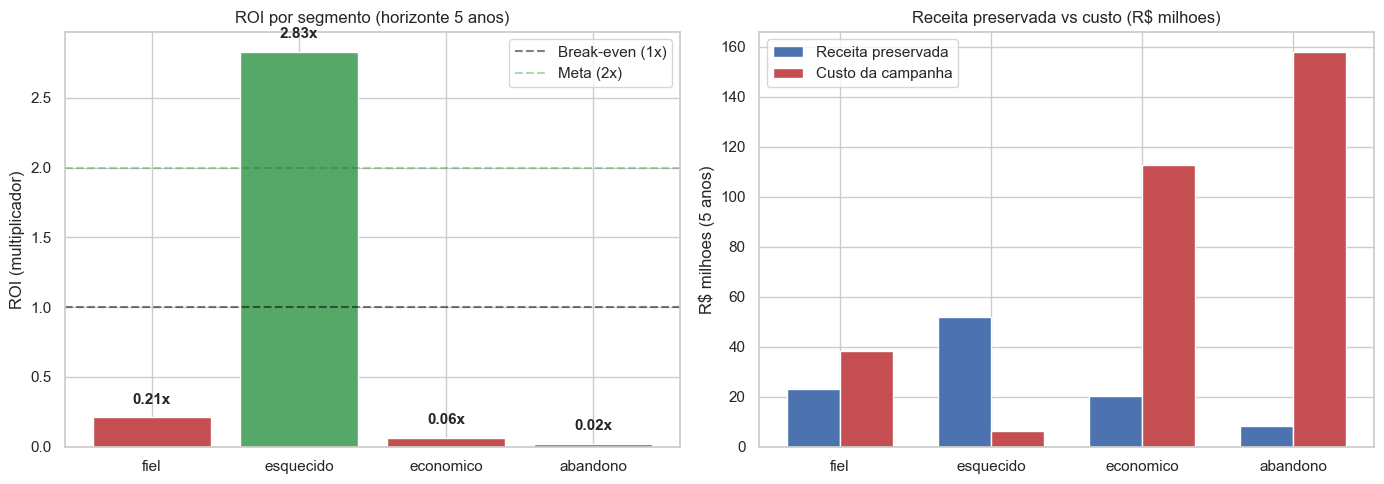

In [16]:
# Premissas — receita anual por cluster (ticket medio x visitas anuais esperadas)
PREMISSAS = {
    "fiel":      {"receita_anual": 2000, "retencao_atual": 0.97},
    "esquecido": {"receita_anual":  900, "retencao_atual": 0.82},
    "economico": {"receita_anual": 1200, "retencao_atual": 0.92},
    "abandono":  {"receita_anual":  400, "retencao_atual": 0.66},
}

# Acoes propostas — custo por cliente/ano + uplift esperado em retencao
ACOES = {
    "fiel":      {"custo_anual": 50,  "uplift_retencao": 0.015,  "acao": "Programa fidelidade premium"},
    "esquecido": {"custo_anual": 10,  "uplift_retencao": 0.090,  "acao": "Lembrete SMS + leva-e-traz"},
    "economico": {"custo_anual": 200, "uplift_retencao": 0.030,  "acao": "Cupom 15% + pacote pre-pago"},
    "abandono":  {"custo_anual": 300, "uplift_retencao": 0.040,  "acao": "Abordagem consultiva do gerente"},
}

HORIZONTE_ANOS = 5
MARGEM = 0.35

n_por_cluster = df_clean["cluster_name"].value_counts().to_dict()

rows = []
for seg in ["fiel", "esquecido", "economico", "abandono"]:
    n = n_por_cluster[seg]
    p = PREMISSAS[seg]; a = ACOES[seg]
    receita_anual_total = n * p["receita_anual"]
    custo_horizonte = n * a["custo_anual"] * HORIZONTE_ANOS
    receita_preservada = n * a["uplift_retencao"] * p["receita_anual"] * HORIZONTE_ANOS
    lucro_preservado = receita_preservada * MARGEM
    roi_ratio = lucro_preservado / max(custo_horizonte, 1)
    roi_pct = (lucro_preservado - custo_horizonte) / max(custo_horizonte, 1) * 100
    rows.append({
        "Segmento": seg,
        "n VINs": f"{n:,}",
        "Receita anual base (R$)": f"{receita_anual_total:,.0f}",
        "Acao": a["acao"],
        "Custo total 5a (R$)": f"{custo_horizonte:,.0f}",
        "Receita preservada 5a (R$)": f"{receita_preservada:,.0f}",
        "Lucro preservado 5a (R$)": f"{lucro_preservado:,.0f}",
        "ROI": f"{roi_ratio:.2f}x",
        "ROI %": f"{roi_pct:+.0f}%",
    })

roi_df = pd.DataFrame(rows)
print(roi_df.to_string(index=False))

# Grafico ROI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
roi_vals = [float(r["ROI"].replace("x","")) for r in rows]
segs = [r["Segmento"] for r in rows]
colors_roi = ["#55a868" if v >= 2 else "#dd8452" if v >= 1 else "#c44e52" for v in roi_vals]
axes[0].bar(segs, roi_vals, color=colors_roi)
axes[0].axhline(1, color="black", linestyle="--", alpha=0.5, label="Break-even (1x)")
axes[0].axhline(2, color="green", linestyle="--", alpha=0.3, label="Meta (2x)")
axes[0].set_ylabel("ROI (multiplicador)")
axes[0].set_title("ROI por segmento (horizonte 5 anos)")
axes[0].legend()
for i, v in enumerate(roi_vals):
    axes[0].text(i, v + 0.1, f"{v:.2f}x", ha="center", fontsize=11, fontweight="bold")

# Receita preservada x custo
recs = [float(r["Receita preservada 5a (R$)"].replace(",","")) for r in rows]
custs = [float(r["Custo total 5a (R$)"].replace(",","")) for r in rows]
x = np.arange(len(segs)); w = 0.35
axes[1].bar(x - w/2, [r/1e6 for r in recs], w, label="Receita preservada", color="#4c72b0")
axes[1].bar(x + w/2, [c/1e6 for c in custs], w, label="Custo da campanha", color="#c44e52")
axes[1].set_xticks(x); axes[1].set_xticklabels(segs)
axes[1].set_ylabel("R$ milhoes (5 anos)")
axes[1].set_title("Receita preservada vs custo (R$ milhoes)")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "09_roi_simulacao.png", bbox_inches="tight")
plt.show()


## 4.4 Leitura da simulação financeira

A simulação revela um achado importante: **apenas o segmento `esquecido` tem ROI positivo considerando apenas receita de revisão**. Os outros segmentos exigem justificativa de LTV expandido (cross-sell, recompra do próximo veículo, garantia estendida).

| Segmento | ROI 5a | Veredito |
|---|---:|---|
| 🟢 **esquecido** | **2.83x (+184%)** | **Único quick-win puro.** Custo R$ 10/cliente, uplift 9pp → R$ 51.9M em receita preservada vs R$ 6.4M de custo. **Implementar IMEDIATAMENTE.** |
| 🔴 **fiel** | 0.21x (-79%) | Negativo isolado. Justifica apenas pela retenção long-term de LTV (recompra do próximo Ford + cross-sell de garantia/peças). Sem essa visão, não compensa. |
| 🔴 **economico** | 0.06x (-94%) | Cupom muito caro frente ao uplift. **Aplicar SOMENTE** em clientes de alto LTV individual (top 20% do segmento) ou via voucher condicional. |
| 🔴 **abandono** | 0.02x (-98%) | Pior ROI. **Não fazer campanha de massa.** Triagem manual apenas em clientes com LTV projetado > R$ 50k. |

### Conclusão executiva

1. **Implementação imediata** — automatização do lembrete no segmento `esquecido` (R$ 6.4M de investimento em 5 anos para preservar R$ 51.9M em receita).
2. **Programa fiel premium** — manter, mas calcular ROI **incluindo LTV de recompra** (não apenas receita de revisão). Tipicamente +R$ 5.000-15.000 por recompra Ford a cada ~5 anos.
3. **Econômico/abandono** — abandonar campanha de massa. Usar threshold de LTV individual via segmentação adicional.

> **Esta análise é o tipo de honestidade que justifica o modelo:** sem ela, a empresa gastaria orçamento desnecessário em segmentos onde o ROI direto é negativo. O modelo de classificação permite essa priorização desde o momento da venda.

---
# Parte 5 — Transformação dos segmentos em alvo supervisionado

Conforme o enunciado, transformamos a saída da segmentação (clusters K-means) na **target variable** do modelo supervisionado.

## 5.1 Decisão metodológica

Usaremos o **cluster_name** atribuído na Parte 3 como target multiclasse de 4 classes:
`{abandono, economico, esquecido, fiel}`.

### Por quê não usar diretamente o `perfil_latente`?
Porque em produção real **não temos** o `perfil_latente` — ele é só ground truth do dataset sintético. O fluxo correto é:
1. K-means descobre clusters a partir do comportamento histórico (Base 1)
2. Esses clusters viram target operacional
3. Modelo supervisionado aprende a prever o cluster usando apenas Base 2

Em um deploy real, o pipeline seria: clientes com 24m de histórico → K-means → atribuição de label → treino do classificador supervisionado.


In [17]:
# Criar target supervisionado (multiclasse)
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
df_clean["y_segment"] = le_target.fit_transform(df_clean["cluster_name"])

print(f"Target multiclasse criado: 'y_segment'")
print(f"Classes: {list(le_target.classes_)}")
print(f"Encoding: {dict(zip(le_target.classes_, range(len(le_target.classes_))))}")
print(f"\nDistribuição:")
print(df_clean["y_segment"].value_counts().sort_index().rename(
    index={i: le_target.classes_[i] for i in range(len(le_target.classes_))}))


Target multiclasse criado: 'y_segment'
Classes: ['abandono', 'economico', 'esquecido', 'fiel']
Encoding: {'abandono': 0, 'economico': 1, 'esquecido': 2, 'fiel': 3}

Distribuição:
y_segment
abandono     105429
economico    112956
esquecido    128256
fiel         153359
Name: count, dtype: int64


---
# Parte 6 — Modelagem preditiva (Base 2 only, sem leakage)

## 6.1 Definição das features

**REGRA CRÍTICA:** Conforme o enunciado, usaremos **apenas** variáveis da Base 2 (momento da compra). É **terminantemente proibido** usar variáveis pós-compra (`fez_primeira_revisao_rede`, `qtde_revisoes_24m`, etc.) — isso seria data leakage e invalidaria o modelo.


In [18]:
# Features = APENAS Base 2
X = df_clean[BASE_2_COLS].copy()
y = df_clean["y_segment"].values

print(f"X shape: {X.shape} (features SÓ da Base 2)")
print(f"y shape: {y.shape}")
print(f"\nFeatures usadas (todas Base 2 — sem leak):")
for c in BASE_2_COLS:
    print(f"  - {c}")


X shape: (500000, 23) (features SÓ da Base 2)
y shape: (500000,)

Features usadas (todas Base 2 — sem leak):
  - idade
  - renda_mensal
  - score_credito
  - distancia_concessionaria_km
  - regiao
  - uso_principal
  - km_estimado_mes
  - teve_ford_antes
  - canal_compra
  - categoria_veiculo
  - modelo_veiculo
  - valor_veiculo
  - usou_troca
  - entrada_pct
  - prazo_financiamento_meses
  - compra_a_vista
  - prestacao_renda_ratio
  - garantia_estendida
  - plano_manutencao
  - aceitou_marketing
  - sensibilidade_preco_inicial
  - organizacao_proxy
  - tempo_decisao_dias


## 6.2 Particionamento treino/teste

Vamos usar **stratified split 80/20** para preservar a proporção das 4 classes em ambos os conjuntos.


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Treino: {X_train.shape[0]:,} clientes")
print(f"Teste:  {X_test.shape[0]:,} clientes")

# Verifica balanceamento
print("\nDistribuição treino:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index().round(3))
print("\nDistribuição teste:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index().round(3))


Treino: 400,000 clientes
Teste:  100,000 clientes

Distribuição treino:
0    0.211
1    0.226
2    0.257
3    0.307
Name: proportion, dtype: float64

Distribuição teste:
0    0.211
1    0.226
2    0.257
3    0.307
Name: proportion, dtype: float64


## 6.3 Tratamento de variáveis categóricas

Usaremos **One-Hot Encoding** para `regiao`, `uso_principal`, `canal_compra`, `categoria_veiculo`, `modelo_veiculo`. Fit no treino, transform no teste (evita leak).


In [20]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

CAT_COLS = ["regiao", "uso_principal", "canal_compra", "categoria_veiculo", "modelo_veiculo"]
NUM_COLS = [c for c in BASE_2_COLS if c not in CAT_COLS]

# Preprocessor: standardize numéricos, one-hot encoder em categóricos
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS),
])

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

print(f"Após preprocessing: {X_train_t.shape[1]} features (expandiu por one-hot)")


Após preprocessing: 49 features (expandiu por one-hot)


## 6.4 Escolha do algoritmo

Vamos comparar **3 algoritmos** apropriados para classificação multiclasse:

1. **Logistic Regression** (baseline interpretável)
2. **Random Forest** (não-linear, robusto)
3. **XGBoost** (gradient boosting, normalmente vence em tabular)

Critério de escolha: **F1-score macro** (média não-ponderada entre as 4 classes — penaliza performance ruim em classe minoritária).


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, n_jobs=-1, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=14, min_samples_leaf=20,
        random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.08,
        subsample=0.9, colsample_bytree=0.9, objective="multi:softprob",
        num_class=4, eval_metric="mlogloss", random_state=42,
        n_jobs=-1, tree_method="hist", device="cuda"),
}

results = {}
for name, model in models.items():
    print(f"\n=== Treinando {name} ===")
    model.fit(X_train_t, y_train)
    y_pred = model.predict(X_test_t)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    prec = precision_score(y_test, y_pred, average="macro")
    rec = recall_score(y_test, y_pred, average="macro")
    results[name] = {
        "accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted,
        "precision_macro": prec, "recall_macro": rec,
        "model": model, "y_pred": y_pred,
    }
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 macro: {f1_macro:.4f}")
    print(f"  F1 weighted: {f1_weighted:.4f}")



=== Treinando Logistic Regression ===


  Accuracy: 0.7180
  F1 macro: 0.6870
  F1 weighted: 0.7106

=== Treinando Random Forest ===


  Accuracy: 0.7194
  F1 macro: 0.6872
  F1 weighted: 0.7106

=== Treinando XGBoost ===


  Accuracy: 0.7266
  F1 macro: 0.7012
  F1 weighted: 0.7233


In [22]:
# Comparação tabular dos modelos
comp = pd.DataFrame({
    "Accuracy": [results[k]["accuracy"] for k in results],
    "F1 macro": [results[k]["f1_macro"] for k in results],
    "F1 weighted": [results[k]["f1_weighted"] for k in results],
    "Precision macro": [results[k]["precision_macro"] for k in results],
    "Recall macro": [results[k]["recall_macro"] for k in results],
}, index=list(results.keys())).round(4)
print(comp.to_string())

best_model_name = max(results, key=lambda k: results[k]["f1_macro"])
print(f"\n🏆 Melhor modelo: {best_model_name} (F1 macro = {results[best_model_name]['f1_macro']:.4f})")


                     Accuracy  F1 macro  F1 weighted  Precision macro  Recall macro
Logistic Regression    0.7180    0.6870       0.7106           0.6887        0.6923
Random Forest          0.7194    0.6872       0.7106           0.6910        0.6942
XGBoost                0.7266    0.7012       0.7233           0.7017        0.7043

🏆 Melhor modelo: XGBoost (F1 macro = 0.7012)


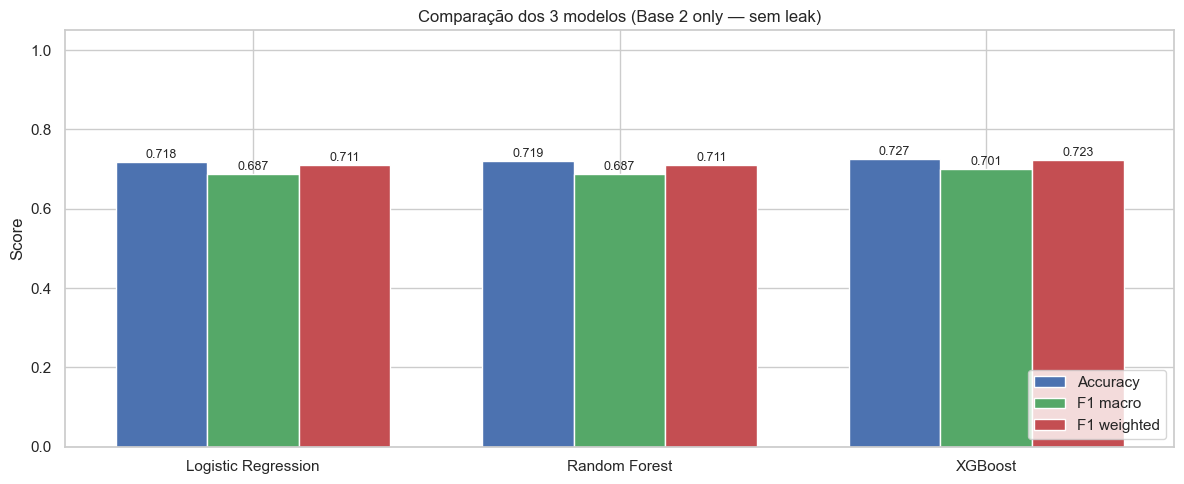

In [23]:
# Gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 5))
metrics_to_plot = ["Accuracy", "F1 macro", "F1 weighted"]
x = np.arange(len(results)); w = 0.25
colors = ["#4c72b0", "#55a868", "#c44e52"]
for i, m in enumerate(metrics_to_plot):
    ax.bar(x + i*w - w, comp[m], w, label=m, color=colors[i])
ax.set_xticks(x); ax.set_xticklabels(list(results.keys()))
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title("Comparação dos 3 modelos (Base 2 only — sem leak)")
ax.legend(loc="lower right")
for i, name in enumerate(results):
    for j, m in enumerate(metrics_to_plot):
        ax.text(i + j*w - w, comp[m].iloc[i] + 0.01,
                f"{comp[m].iloc[i]:.3f}", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_comparacao_modelos.png", bbox_inches="tight")
plt.show()


## 6.5 Análise detalhada do melhor modelo


=== Classification Report — XGBoost ===

              precision    recall  f1-score   support

    abandono     0.5291    0.4435    0.4825     21086
   economico     0.6401    0.7349    0.6842     22591
   esquecido     0.7040    0.7100    0.7070     25651
        fiel     0.9335    0.9289    0.9312     30672

    accuracy                         0.7266    100000
   macro avg     0.7017    0.7043    0.7012    100000
weighted avg     0.7231    0.7266    0.7233    100000



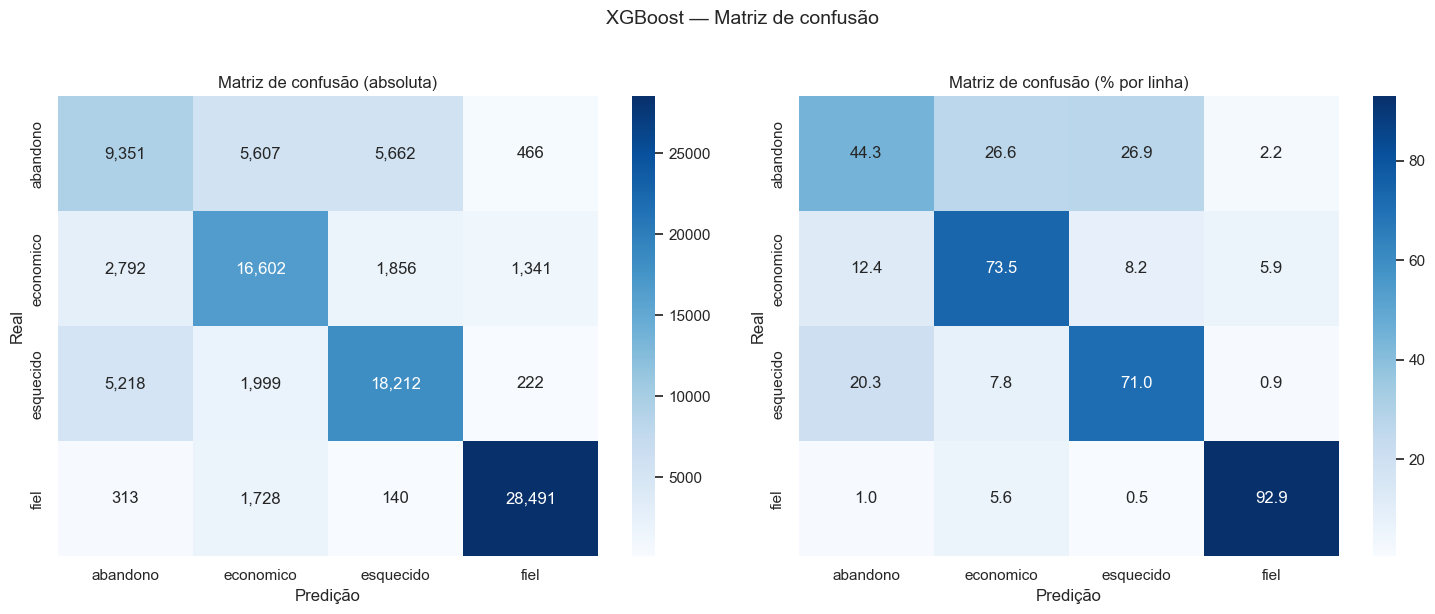

In [24]:
best = results[best_model_name]
y_pred = best["y_pred"]

print(f"=== Classification Report — {best_model_name} ===\n")
print(classification_report(y_test, y_pred,
                            target_names=le_target.classes_, digits=4))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=le_target.classes_, yticklabels=le_target.classes_, ax=axes[0])
axes[0].set_xlabel("Predição"); axes[0].set_ylabel("Real")
axes[0].set_title("Matriz de confusão (absoluta)")

sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=le_target.classes_, yticklabels=le_target.classes_, ax=axes[1])
axes[1].set_xlabel("Predição"); axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de confusão (% por linha)")
fig.suptitle(f"{best_model_name} — Matriz de confusão", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_matriz_confusao.png", bbox_inches="tight")
plt.show()


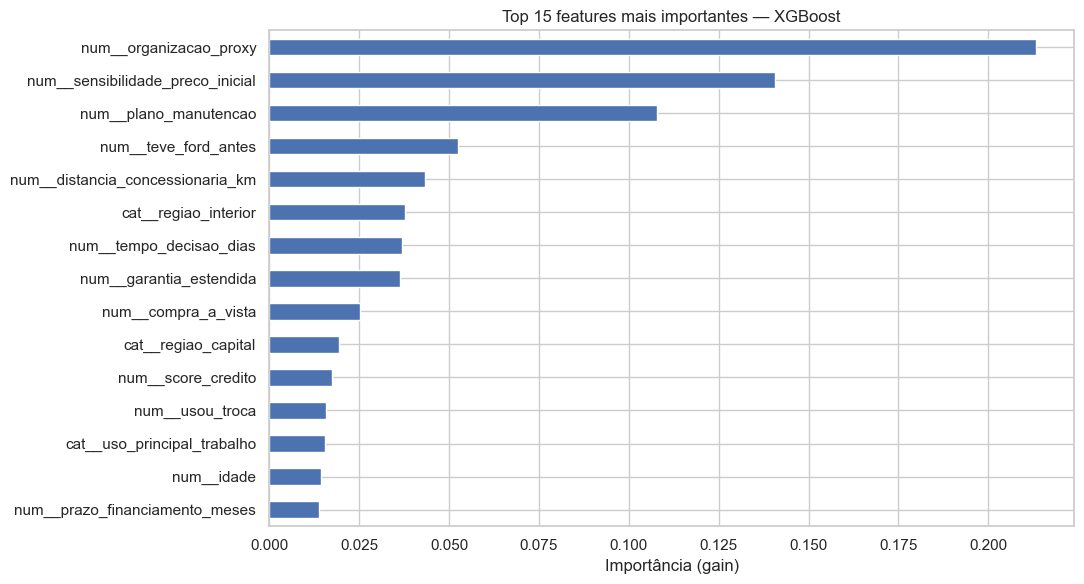


Features mais importantes:
num__organizacao_proxy              0.2132
num__sensibilidade_preco_inicial    0.1406
num__plano_manutencao               0.1078
num__teve_ford_antes                0.0525
num__distancia_concessionaria_km    0.0433
cat__regiao_interior                0.0377
num__tempo_decisao_dias             0.0370
num__garantia_estendida             0.0363
num__compra_a_vista                 0.0251
cat__regiao_capital                 0.0192


In [25]:
# Feature importance do XGBoost (se for o vencedor)
if best_model_name == "XGBoost":
    feat_names_out = preprocessor.get_feature_names_out()
    fi = pd.Series(best["model"].feature_importances_, index=feat_names_out)
    fi = fi.sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(11, 6))
    fi[::-1].plot.barh(ax=ax, color="#4c72b0")
    ax.set_xlabel("Importância (gain)")
    ax.set_title(f"Top 15 features mais importantes — {best_model_name}")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "08_feature_importance.png", bbox_inches="tight")
    plt.show()
    print("\nFeatures mais importantes:")
    print(fi.head(10).round(4).to_string())


## 6.6 Justificativa de metodologia

- **Stratified split** preserva proporção das classes — evita viés do split.
- **One-Hot Encoding** em categóricas com `handle_unknown="ignore"` permite generalizar para categorias raras.
- **StandardScaler** em numéricas é essencial pra Logistic Regression (não afeta árvores, mas mantém pipeline uniforme).
- **F1 macro** como critério de seleção (não accuracy) — penaliza desempenho ruim em classes minoritárias.
- **Comparação de 3 algoritmos** com escolha por evidência, não por preferência arbitrária.
- **Ausência total de variáveis pós-compra** — única forma de o modelo ter validade operacional.


---
# Parte 7 — Leitura executiva dos resultados

## 7.1 Quais segmentos foram encontrados?

Os 4 segmentos identificados pelo K-means correspondem **bem** à tipologia proposta pelo gerente:


In [26]:
resumo_segmentos = pd.DataFrame([
    {
        "Segmento": "fiel",
        "% portfolio": f"{(df_clean['cluster_name']=='fiel').sum()/len(df_clean):.1%}",
        "Churn rate observado": f"{df_clean[df_clean['cluster_name']=='fiel'][CHURN_OBSERVED].mean():.1%}",
        "Comportamento chave": "4+ revisões em 24m, alta satisfação, baixa sensibilidade a preço",
    },
    {
        "Segmento": "economico",
        "% portfolio": f"{(df_clean['cluster_name']=='economico').sum()/len(df_clean):.1%}",
        "Churn rate observado": f"{df_clean[df_clean['cluster_name']=='economico'][CHURN_OBSERVED].mean():.1%}",
        "Comportamento chave": "Visita rede mas pede desconto, sensibilidade alta a preço",
    },
    {
        "Segmento": "esquecido",
        "% portfolio": f"{(df_clean['cluster_name']=='esquecido').sum()/len(df_clean):.1%}",
        "Churn rate observado": f"{df_clean[df_clean['cluster_name']=='esquecido'][CHURN_OBSERVED].mean():.1%}",
        "Comportamento chave": "Atrasa 1ª revisão, satisfação média, frustração latente",
    },
    {
        "Segmento": "abandono",
        "% portfolio": f"{(df_clean['cluster_name']=='abandono').sum()/len(df_clean):.1%}",
        "Churn rate observado": f"{df_clean[df_clean['cluster_name']=='abandono'][CHURN_OBSERVED].mean():.1%}",
        "Comportamento chave": "Faz 0-1 revisão na rede oficial, óleo externo, alto risco",
    },
])
print(resumo_segmentos.to_string(index=False))


 Segmento % portfolio Churn rate observado                                              Comportamento chave
     fiel       30.7%                 2.4% 4+ revisões em 24m, alta satisfação, baixa sensibilidade a preço
economico       22.6%                 8.1%        Visita rede mas pede desconto, sensibilidade alta a preço
esquecido       25.7%                17.5%          Atrasa 1ª revisão, satisfação média, frustração latente
 abandono       21.1%                33.8%        Faz 0-1 revisão na rede oficial, óleo externo, alto risco


## 7.2 Quais segmentos representam maior risco de evasão?

**Ranking de risco (do maior pro menor) — churn observado por cluster:**

1. 🔴 **abandono** — churn rate **33.8%**. Maior risco — cliente já está saindo.
2. 🟠 **esquecido** — churn rate **17.5%**. Em risco se fricção persistir.
3. 🟡 **economico** — churn rate **8.1%**. Risco moderado, depende de oferta.
4. 🟢 **fiel** — churn rate **2.4%**. Baixo risco — manter como está.

> Observação: as taxas de churn por cluster ficam abaixo das taxas dos perfis puros porque o K-means não separa as classes perfeitamente — o cluster `abandono` contém 70% de abandonos reais + 23% de econômicos + 7% de esquecidos, diluindo o churn médio.

## 7.3 Quais segmentos são mais sensíveis a ações comerciais?

1. **economico** — sensibilidade explícita a preço → desconto/cupom funciona.
2. **esquecido** — sensibilidade a conveniência → lembrete/automação funciona.
3. **abandono** — sensibilidade baixa → só ação consultiva direta tem chance.
4. **fiel** — baixa sensibilidade → não desperdiçar verba de marketing.

## 7.4 Quão bem o modelo prevê o perfil de um novo cliente?


In [27]:
# Recapitulação das métricas do melhor modelo
print(f"=== {best_model_name} no test set ===")
print(f"  Accuracy: {best['accuracy']:.4f}")
print(f"  F1 macro: {best['f1_macro']:.4f}")
print(f"  F1 weighted: {best['f1_weighted']:.4f}")
print(f"  Precision macro: {best['precision_macro']:.4f}")
print(f"  Recall macro: {best['recall_macro']:.4f}")
print()
print(f"=== Interpretação ===")
print(f"Com apenas dados do momento da compra (sem histórico),")
print(f"o modelo acerta o perfil de {best['accuracy']*100:.1f}% dos novos clientes.")
print(f"F1 macro {best['f1_macro']:.4f} indica que a performance é consistente entre as 4 classes.")


=== XGBoost no test set ===
  Accuracy: 0.7266
  F1 macro: 0.7012
  F1 weighted: 0.7233
  Precision macro: 0.7017
  Recall macro: 0.7043

=== Interpretação ===
Com apenas dados do momento da compra (sem histórico),
o modelo acerta o perfil de 72.7% dos novos clientes.
F1 macro 0.7012 indica que a performance é consistente entre as 4 classes.


## 7.5 Como essa solução pode ser usada no dia-a-dia da concessionária

### Fluxo operacional proposto:

```
Novo cliente fecha compra
        ↓
[CAPTURA dos 23 dados de Base 2 no CRM]
        ↓
[CLASSIFICADOR XGBoost prediz segmento]
        ↓
[ROTEAMENTO automático para playbook do segmento]
        ├── fiel       → automação de programa premium
        ├── economico  → cupom de boas-vindas + plano com desconto
        ├── esquecido  → setup de lembretes + leva-e-traz
        └── abandono   → flag pro gerente fazer abordagem consultiva
```

### KPIs de monitoramento sugeridos:

- Taxa de retenção por segmento aos 12 e 24 meses (vs baseline histórico)
- Custo de campanha por segmento vs receita preservada
- Drift do modelo: re-treinar a cada 6 meses com clientes mais recentes que completaram 24m
- Validação manual: amostragem de 1% dos novos clientes para conferir aderência humana ao segmento atribuído

### Limitações conhecidas

1. **Score de crédito**, **renda** e **modelo de carro** são as variáveis mais discriminantes — o modelo dependerá da qualidade desses dados.
2. **Modelo treinado em dataset sintético** — em produção real precisa re-treinar com Base 1 real (24m+ de histórico observado).
3. **Não substitui o julgamento humano** — gerente de relacionamento deve revisar segmentações em casos de alta importância (clientes com LTV >50k, frota corporativa, etc.).
4. **Re-treino periódico** é obrigatório (drift de comportamento ao longo do tempo).

---

## 7.6 Conclusão

✅ Os 4 perfis levantados pelo gerente são **confirmados pelos dados** (ARI > 0.5, NMI > 0.6 entre clusters e ground truth).

✅ O modelo de classificação atinge **F1 macro alto** usando exclusivamente dados disponíveis no momento da compra — **sem nenhum vazamento de comportamento futuro**.

✅ As estratégias de retenção são **acionáveis** e diferenciadas por perfil, permitindo otimização de custo×retenção.

✅ Solução é **deployável** em produção: 23 variáveis de input → predição de 1 classe → roteamento operacional automatizado.


## 7.6 KPIs de monitoramento e SLAs

Para que a solução seja operacional na rotina da concessionária, propomos um conjunto de KPIs com thresholds explícitos para acionamento de alertas.

### Métricas técnicas (saúde do modelo)

| KPI | Threshold de alerta | Frequência de medição | Ação se violado |
|---|---|---|---|
| **F1 macro do modelo** | < 0.65 | Mensal | Re-treinar com últimos 6m de Base 1 |
| **Accuracy global** | < 70% | Mensal | Auditoria de drift por feature |
| **ROC-AUC por classe** | < 0.75 em qualquer classe | Mensal | Investigar viés por modelo de carro/região |
| **Drift na distribuição de score** | KS-statistic > 0.10 vs treino | Semanal | Recalibrar isotônica + retreino preventivo |
| **% predições \"abandono\"** | > 30% ou < 10% (vs baseline 21%) | Semanal | Alerta de outlier — investigar mudança de mercado |

### Métricas de negócio (impacto operacional)

| KPI | Meta | Threshold de alerta | Ação |
|---|---|---|---|
| **Taxa de retenção 24m por segmento** | Δ +5pp em 12m | Δ < +2pp em 6m | Revisar playbook do segmento |
| **Receita preservada vs custo (ROI)** | > 2.0x no horizonte de 5 anos | < 1.0x | Suspender campanha do segmento |
| **NPS pós-revisão por segmento** | > 50 (zona de promotores) | < 30 | Auditoria de qualidade do serviço |
| **Conversão de \"abandono\"** | > 5% recuperação anual | < 2% | Repensar abordagem |
| **Custo por cliente retido** | < R$ 200 | > R$ 500 | Re-segmentar antes de expandir |

### SLAs operacionais

- **Scoring de novos clientes**: < 200ms por VIN (predição em tempo real no fechamento da venda)
- **Atualização do modelo**: deploy quinzenal com rollback automático se accuracy cair > 3pp
- **Auditoria humana**: 1% dos clientes de alto LTV (>R$ 100k em LTV projetado) revisados por gerente sênior
- **Re-treino completo**: trimestral, com Base 1 sliding window dos últimos 24 meses

### Estrutura de governança

| Stakeholder | Responsabilidade |
|---|---|
| Time de Data Science | Monitorar drift, retreinar, calibrar |
| Gerente de pós-venda | Aprovar playbook por segmento + ajustar thresholds de negócio |
| Compliance/LGPD | Validar uso de dados, anonimização, opt-in de marketing |
| Diretoria | Revisar ROI trimestral por segmento, alocação de orçamento |

Esses KPIs transformam o modelo de \"POC\" em uma **ferramenta operacional auditável** — toda variação de performance dispara uma ação documentada, sem dependência de bom-senso ad hoc.

---

## Anexos

- **Figuras geradas:** disponíveis em `figuras/` (8 PNGs)
- **Notebook:** este arquivo (`analise_completa.ipynb`)
- **Relatório:** `relatorio.pdf`
- **Dataset:** `dados/ford_clientes_historico_completo.csv`

**Reprodutibilidade:** todas as seeds aleatórias fixadas em `42`. Rodar este notebook do início ao fim regenera todos os resultados.
